In [22]:
from pathlib import Path
import json
import pandas as pd
import re
import matplotlib.pyplot as plt


In [23]:
BASE_DIR = Path("../dataset_comparative_2020_2026")
COMPARATIVE_DIR = BASE_DIR / "comparative_files"

METRICS_SOURCES = [
    {
        "method": "YAKE",
        "mode": "original",
        "path": COMPARATIVE_DIR / "yake_metrics"
    },
    {
        "method": "YAKE",
        "mode": "filtered",
        "path": COMPARATIVE_DIR / "yake_Filtred_metrics"
    },
    {
        "method": "KeyBERT",
        "mode": "original",
        "path": COMPARATIVE_DIR / "keyBert_metrics"
    },
    {
        "method": "KeyBERT",
        "mode": "filtered",
        "path": COMPARATIVE_DIR / "keyBert_Filtred_metrics"
    },
]

In [24]:
def extract_filter_percent(filename):
    filename = filename.lower()

    # filtered-файли: keywords_keybert_filtered_10pct_2_metrics.json
    match = re.search(r"(\d+)pct", filename)
    if match:
        return int(match.group(1))

    # old/original-файли: keybert_min10_2_metrics.json або yake_min10_2_metrics.json
    match = re.search(r"min(2|4|6|8|10)", filename)
    if match:
        return int(match.group(1))

    return None

In [25]:
rows = []

for source in METRICS_SOURCES:
    method = source["method"]
    mode = source["mode"]
    folder = source["path"]

    print(f"Reading: {method} / {mode} -> {folder}")

    if not folder.exists():
        print(f"  Folder not found: {folder}")
        continue

    metrics_files = sorted(folder.glob("*metrics.json"))

    print(f"  Found metrics files: {len(metrics_files)}")

    for file_path in metrics_files:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        row = {
            "method": method,
            "mode": mode,
            "filter_percent": extract_filter_percent(file_path.name),
            "file": file_path.name,

            "num_nodes": data.get("num_nodes"),
            "num_edges": data.get("num_edges"),
            "density": data.get("density"),

            "is_connected": data.get("is_connected"),
            "num_components": data.get("num_components"),
            "largest_component_size": data.get("largest_component_size"),
            "largest_component_pct": data.get("largest_component_pct"),
            "isolated_nodes": data.get("isolated_nodes"),

            "avg_degree": data.get("avg_degree"),
            "max_degree": data.get("max_degree"),
            "min_degree": data.get("min_degree"),

            "clustering_coefficient": data.get("clustering_coefficient"),
            "transitivity": data.get("transitivity"),
            "avg_shortest_path_length": data.get("avg_shortest_path_length"),
            "random_graph_avg_path": data.get("random_graph_avg_path"),
            "random_graph_clustering": data.get("random_graph_clustering"),
            "is_small_world": data.get("is_small_world"),

            "degree_assortativity": data.get("degree_assortativity"),
            "num_communities_louvain": data.get("num_communities_louvain"),
            "modularity": data.get("modularity"),

            "min_shared_keywords": data.get("min_shared_keywords"),
            "total_time_seconds": data.get("total_time_seconds"),
        }

        rows.append(row)

summary_df = pd.DataFrame(rows)

summary_df = summary_df.sort_values(
    ["method", "mode", "filter_percent"]
).reset_index(drop=True)

display(summary_df)
print("Rows:", len(summary_df))

Reading: YAKE / original -> ..\dataset_comparative_2020_2026\comparative_files\yake_metrics
  Found metrics files: 5
Reading: YAKE / filtered -> ..\dataset_comparative_2020_2026\comparative_files\yake_Filtred_metrics
  Found metrics files: 5
Reading: KeyBERT / original -> ..\dataset_comparative_2020_2026\comparative_files\keyBert_metrics
  Found metrics files: 5
Reading: KeyBERT / filtered -> ..\dataset_comparative_2020_2026\comparative_files\keyBert_Filtred_metrics
  Found metrics files: 5


,method,mode,filter_percent,file,num_nodes,num_edges,density,is_connected,num_components,largest_component_size,...,transitivity,avg_shortest_path_length,random_graph_avg_path,random_graph_clustering,is_small_world,degree_assortativity,num_communities_louvain,modularity,min_shared_keywords,total_time_seconds
0,KeyBERT,filtered,2,keywords_keybert_filtered_2pct_2_metrics.json,8257,250904,0.007361,False,2065,6098,...,0.302011,2.8616,1.9764,0.013489,True,0.122025,18,0.461321,2,None
1,KeyBERT,filtered,4,keywords_keybert_filtered_4pct_2_metrics.json,8082,246372,0.007545,False,2010,5984,...,0.298948,2.8624,1.9719,0.013755,True,0.122987,18,0.458828,2,None
2,KeyBERT,filtered,6,keywords_keybert_filtered_6pct_2_metrics.json,7918,243260,0.007761,False,1936,5896,...,0.297500,2.8444,1.9675,0.013990,True,0.122989,20,0.444912,2,None
3,KeyBERT,filtered,8,keywords_keybert_filtered_8pct_2_metrics.json,7748,239449,0.007978,False,1897,5769,...,0.296251,2.8081,1.9599,0.014384,True,0.124043,15,0.445474,2,None
4,KeyBERT,filtered,10,keywords_keybert_filtered_10pct_2_metrics.json,7582,236663,0.008235,False,1847,5660,...,0.294884,2.7964,1.9524,0.014770,True,0.125280,22,0.435210,2,None
5,KeyBERT,original,2,keybert_min2_2_metrics.json,8257,2263367,0.066404,False,1466,6765,...,0.588345,2.0588,1.3556,0.098925,False,0.153940,12,0.360567,2,None
6,KeyBERT,original,4,keybert_min4_2_metrics.json,8082,2134679,0.065370,False,1437,6621,...,0.578951,2.0702,1.3600,0.097403,False,0.147661,13,0.359951,2,None
7,KeyBERT,original,6,keybert_min6_2_metrics.json,7918,2031700,0.064821,False,1394,6503,...,0.571706,2.0785,1.3639,0.096100,False,0.143150,12,0.360253,2,None
8,KeyBERT,original,8,keybert_min8_2_metrics.json,7748,1906254,0.063517,False,1374,6356,...,0.561654,2.0851,1.3690,0.094386,False,0.136913,14,0.357171,2,None
9,KeyBERT,original,10,keybert_min10_2_metrics.json,7582,1800312,0.062642,False,1351,6214,...,0.551610,2.0612,1.3729,0.093261,False,0.129853,11,0.357018,2,None


Rows: 20


In [26]:
main_metrics_df = summary_df[
    [
        "method",
        "mode",
        "filter_percent",
        "num_nodes",
        "num_edges",
        "density",
        "largest_component_pct",
        "isolated_nodes",
        "clustering_coefficient",
        "transitivity",
        "avg_shortest_path_length",
        "avg_degree",
        "max_degree",
        "modularity",
        "is_small_world",
    ]
].sort_values(["method", "mode", "filter_percent"])

display(main_metrics_df)

,method,mode,filter_percent,num_nodes,num_edges,density,largest_component_pct,isolated_nodes,clustering_coefficient,transitivity,avg_shortest_path_length,avg_degree,max_degree,modularity,is_small_world
0,KeyBERT,filtered,2,8257,250904,0.007361,73.85,1994,0.438143,0.302011,2.8616,60.7736,778,0.461321,True
1,KeyBERT,filtered,4,8082,246372,0.007545,74.04,1943,0.432142,0.298948,2.8624,60.9681,764,0.458828,True
2,KeyBERT,filtered,6,7918,243260,0.007761,74.46,1870,0.428593,0.297500,2.8444,61.4448,754,0.444912,True
3,KeyBERT,filtered,8,7748,239449,0.007978,74.46,1834,0.422959,0.296251,2.8081,61.8092,737,0.445474,True
4,KeyBERT,filtered,10,7582,236663,0.008235,74.65,1790,0.419197,0.294884,2.7964,62.4276,726,0.435210,True
5,KeyBERT,original,2,8257,2263367,0.066404,81.93,1444,0.593491,0.588345,2.0588,548.2299,3726,0.360567,False
6,KeyBERT,original,4,8082,2134679,0.065370,81.92,1416,0.588746,0.578951,2.0702,528.2551,3618,0.359951,False
7,KeyBERT,original,6,7918,2031700,0.064821,82.13,1375,0.585692,0.571706,2.0785,513.1851,3525,0.360253,False
8,KeyBERT,original,8,7748,1906254,0.063517,82.03,1357,0.580442,0.561654,2.0851,492.0635,3416,0.357171,False
9,KeyBERT,original,10,7582,1800312,0.062642,81.96,1334,0.575664,0.551610,2.0612,474.8911,3315,0.357018,False


In [27]:
full_output_path = COMPARATIVE_DIR / "network_metrics_summary_full.csv"
main_output_path = COMPARATIVE_DIR / "network_metrics_summary_main.csv"

summary_df.to_csv(full_output_path, index=False, encoding="utf-8-sig")
main_metrics_df.to_csv(main_output_path, index=False, encoding="utf-8-sig")

print("Saved full summary:")
print(full_output_path)

print("\nSaved main summary:")
print(main_output_path)

Saved full summary:
..\dataset_comparative_2020_2026\comparative_files\network_metrics_summary_full.csv

Saved main summary:
..\dataset_comparative_2020_2026\comparative_files\network_metrics_summary_main.csv


In [28]:
check_df = (
    summary_df
    .groupby(["method", "mode"])
    .size()
    .reset_index(name="count")
)

display(check_df)

print("Total rows:", len(summary_df))

,method,mode,count
0,KeyBERT,filtered,5
1,KeyBERT,original,5
2,YAKE,filtered,5
3,YAKE,original,5


Total rows: 20


In [29]:
FIGURES_DIR = COMPARATIVE_DIR / "network_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(FIGURES_DIR)

..\dataset_comparative_2020_2026\comparative_files\network_figures


In [30]:
METHOD_COLORS = {
    "YAKE": "tab:orange",
    "KeyBERT": "tab:blue",
}

METHOD_MARKERS = {
    "YAKE": "^",
    "KeyBERT": "o",
}

MODE_LINESTYLES = {
    "original": "--",
    "filtered": "-",
}

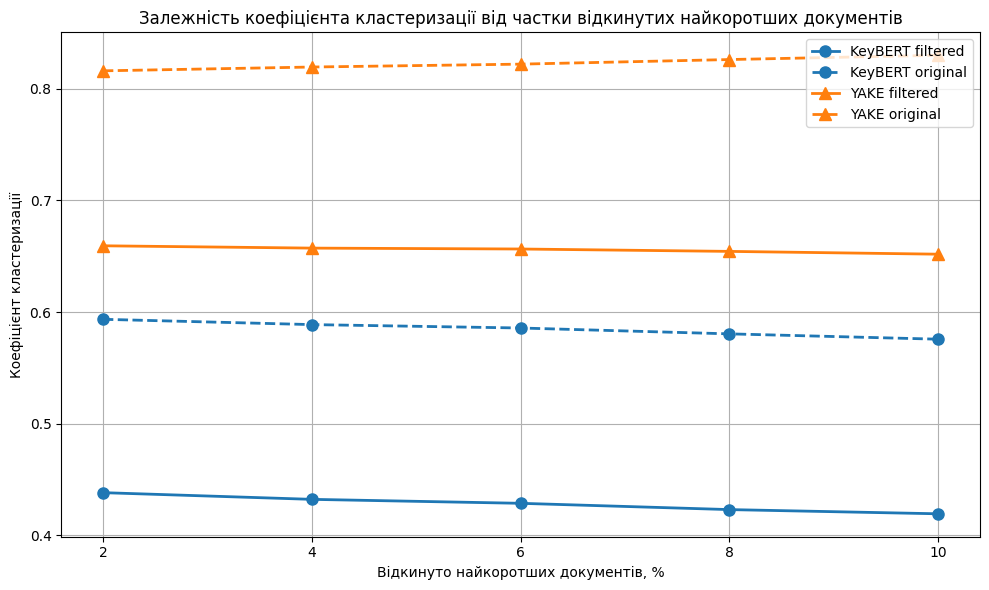

Saved: ..\dataset_comparative_2020_2026\comparative_files\network_figures\clustering_vs_removed_shortest_docs.png


In [31]:
metric = "clustering_coefficient"

plt.figure(figsize=(10, 6))

for (method, mode), part in summary_df.groupby(["method", "mode"]):
    part = part.sort_values("filter_percent")

    plt.plot(
        part["filter_percent"],
        part[metric],
        color=METHOD_COLORS.get(method),
        marker=METHOD_MARKERS.get(method, "o"),
        linestyle=MODE_LINESTYLES.get(mode, "-"),
        linewidth=2,
        markersize=8,
        label=f"{method} {mode}"
    )

plt.title("Залежність коефіцієнта кластеризації від частки відкинутих найкоротших документів")
plt.xlabel("Відкинуто найкоротших документів, %")
plt.ylabel("Коефіцієнт кластеризації")
plt.xticks([2, 4, 6, 8, 10])
plt.grid(True)
plt.legend()
plt.tight_layout()

output_path = FIGURES_DIR / "clustering_vs_removed_shortest_docs.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

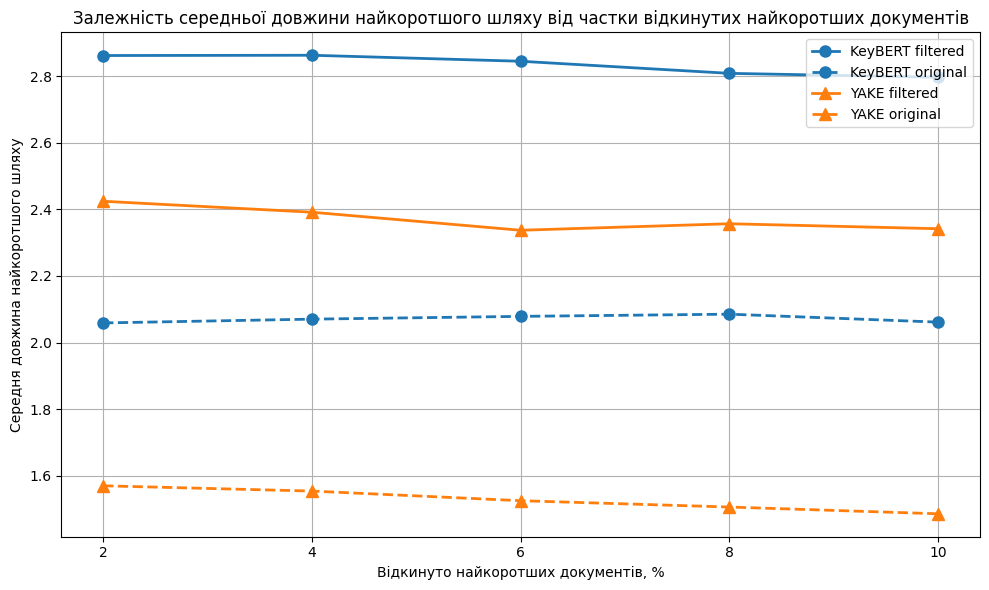

Saved: ..\dataset_comparative_2020_2026\comparative_files\network_figures\avg_shortest_path_vs_removed_shortest_docs.png


In [32]:
metric = "avg_shortest_path_length"

plt.figure(figsize=(10, 6))

for (method, mode), part in summary_df.groupby(["method", "mode"]):
    part = part.sort_values("filter_percent")

    plt.plot(
        part["filter_percent"],
        part[metric],
        color=METHOD_COLORS.get(method),
        marker=METHOD_MARKERS.get(method, "o"),
        linestyle=MODE_LINESTYLES.get(mode, "-"),
        linewidth=2,
        markersize=8,
        label=f"{method} {mode}"
    )

plt.title("Залежність середньої довжини найкоротшого шляху від частки відкинутих найкоротших документів")
plt.xlabel("Відкинуто найкоротших документів, %")
plt.ylabel("Середня довжина найкоротшого шляху")
plt.xticks([2, 4, 6, 8, 10])
plt.grid(True)
plt.legend()
plt.tight_layout()

output_path = FIGURES_DIR / "avg_shortest_path_vs_removed_shortest_docs.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

In [33]:
def find_degree_file(method, mode, filter_percent):
    method = method.lower()
    mode = mode.lower()
    pct = int(filter_percent)

    if method == "keybert" and mode == "filtered":
        folder = COMPARATIVE_DIR / "keyBert_Filtred_metrics"
    elif method == "keybert" and mode == "original":
        folder = COMPARATIVE_DIR / "keyBert_metrics"
    elif method == "yake" and mode == "filtered":
        folder = COMPARATIVE_DIR / "yake_Filtred_metrics"
    elif method == "yake" and mode == "original":
        folder = COMPARATIVE_DIR / "yake_metrics"
    else:
        raise ValueError("Unknown method/mode")

    files = sorted([
        p for p in folder.glob("*.json")
        if "degree" in p.name.lower()
    ])

    candidates = []

    for p in files:
        name = p.name.lower()

        has_percent = (
            f"{pct}pct" in name
            or f"min{pct}" in name
            or f"_{pct}_" in name
        )

        if has_percent:
            candidates.append(p)

    if not candidates:
        raise FileNotFoundError(f"Не знайдено degree distribution для {method} {mode} {pct}% у {folder}")

    return candidates[0]

Degree file: ..\dataset_comparative_2020_2026\comparative_files\keyBert_Filtred_metrics\keywords_keybert_filtered_10pct_2_degree_distribution.json


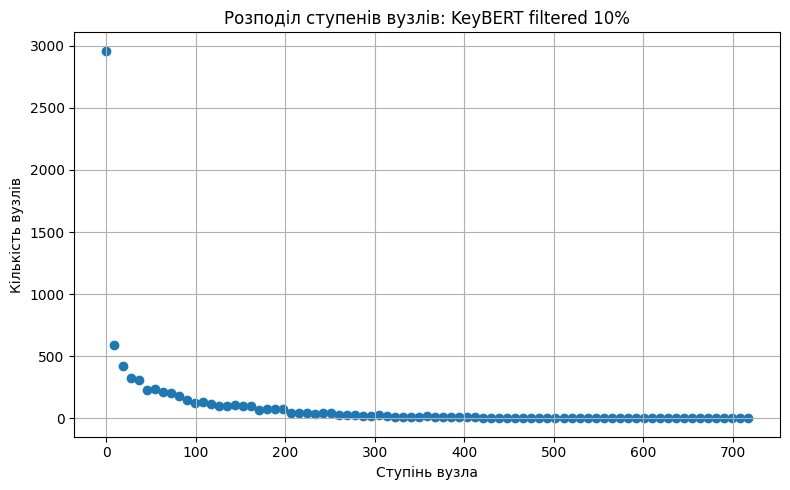

Saved: ..\dataset_comparative_2020_2026\comparative_files\network_figures\degree_distribution_keybert_filtered_10pct.png


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import json

degree_file = find_degree_file(
    method="KeyBERT",
    mode="filtered",
    filter_percent=2
)

print("Degree file:", degree_file)

with open(degree_file, "r", encoding="utf-8") as f:
    degree_dist = json.load(f)

data = []

for degree, count in degree_dist.items():
    data.extend([int(degree)] * int(count))

data = np.array(data)

hist, bin_edges = np.histogram(data, bins="fd")

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(bin_edges[:-1], hist)

ax.set_title("Розподіл ступенів вузлів: KeyBERT filtered 10%")
ax.set_xlabel("Ступінь вузла")
ax.set_ylabel("Кількість вузлів")
ax.grid(True)

plt.tight_layout()

output_path = FIGURES_DIR / "degree_distribution_keybert_filtered_10pct.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", output_path)

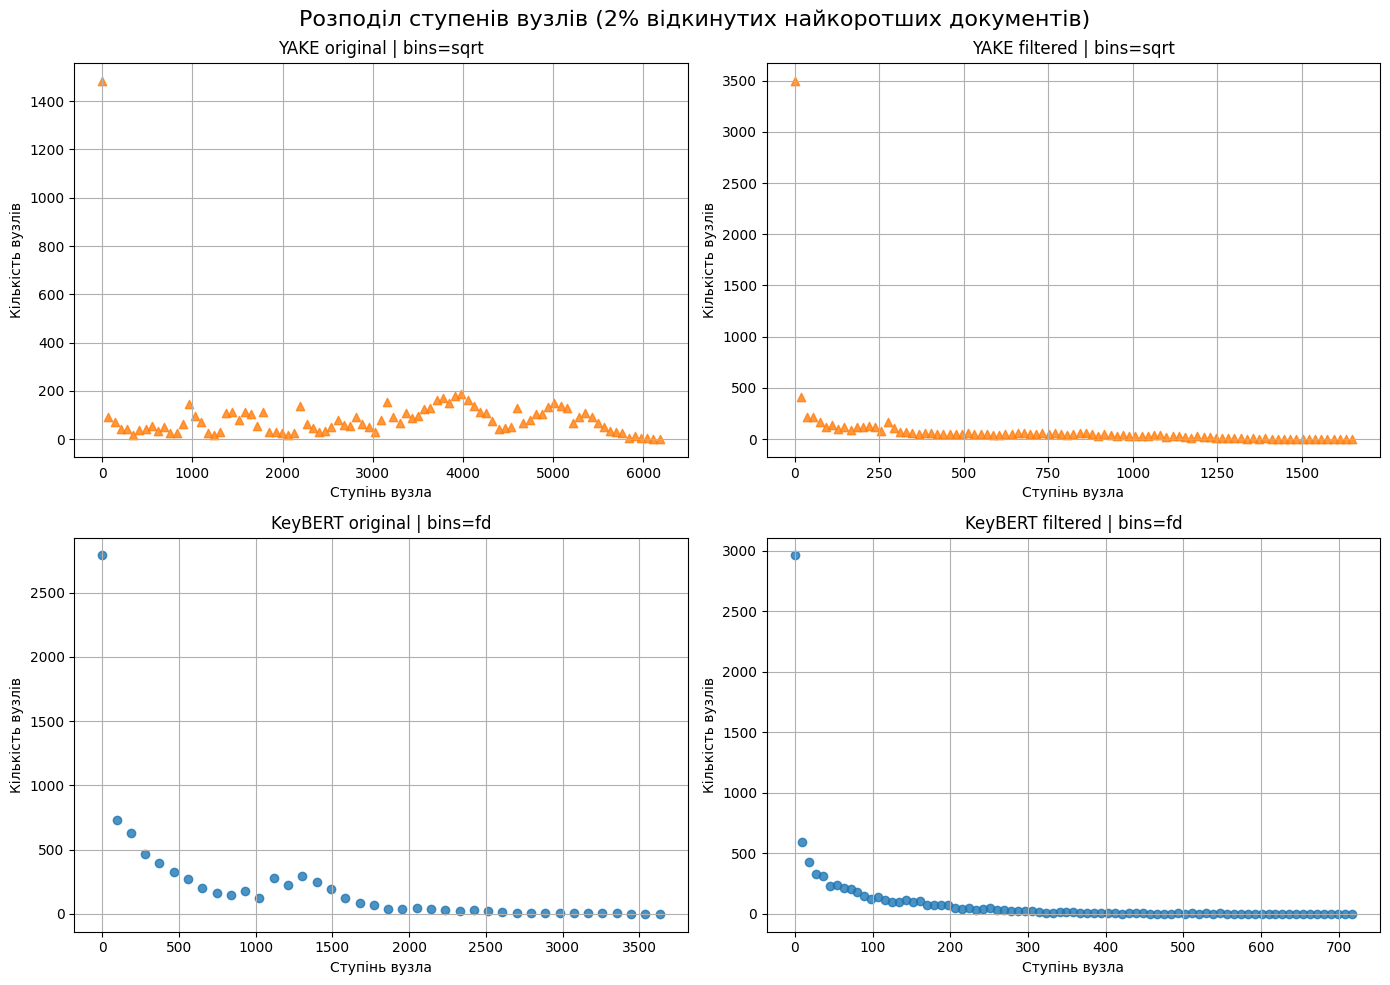

Saved: ..\dataset_comparative_2020_2026\comparative_files\network_figures\degree_distribution_4_variants_2pct.png


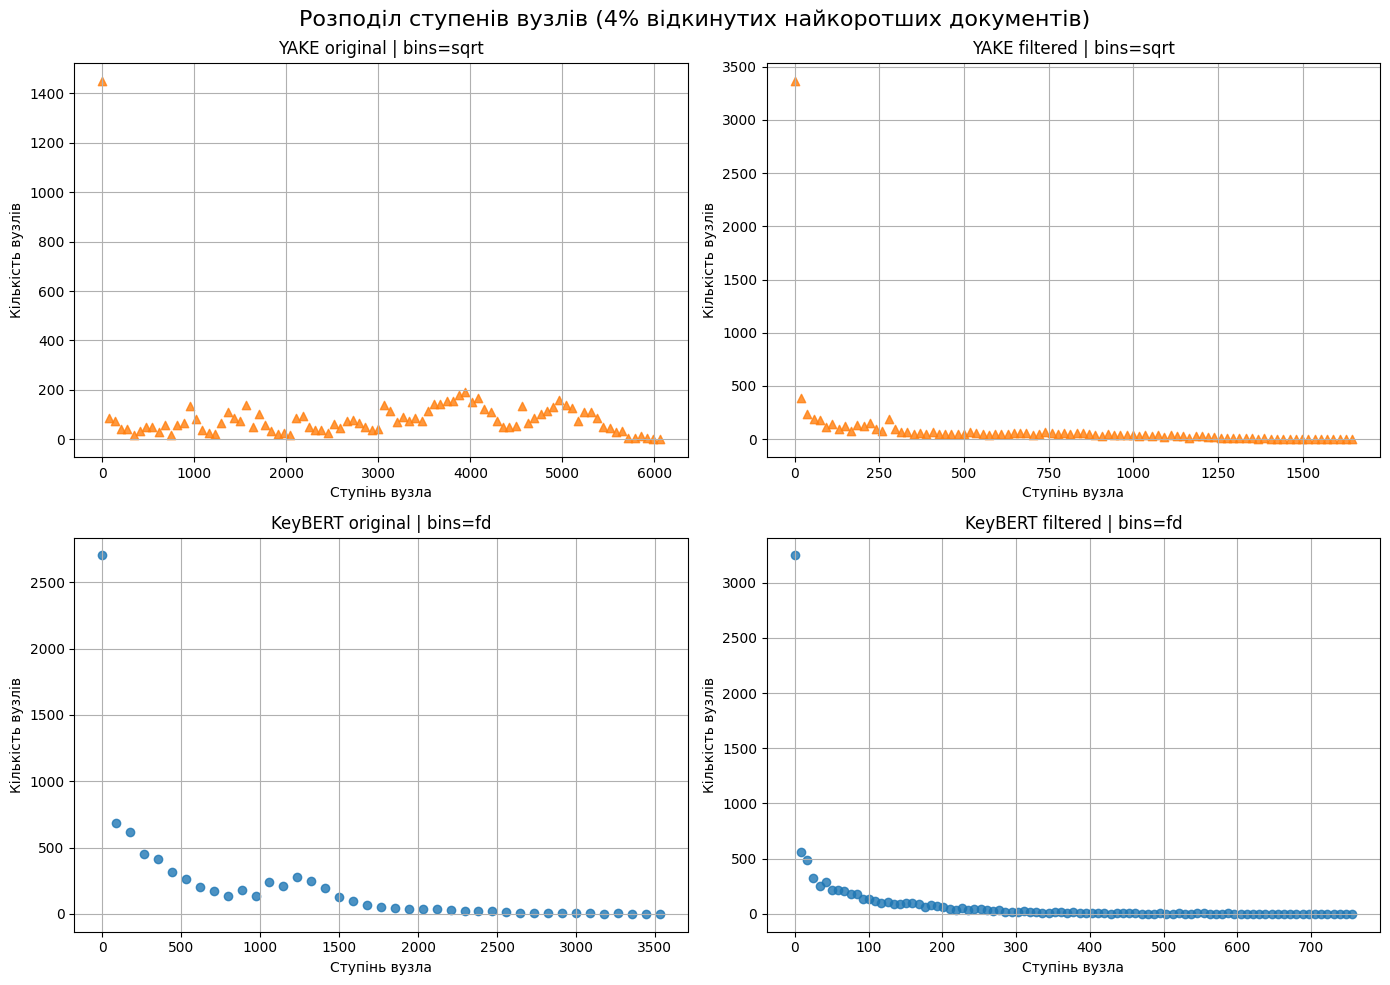

Saved: ..\dataset_comparative_2020_2026\comparative_files\network_figures\degree_distribution_4_variants_4pct.png


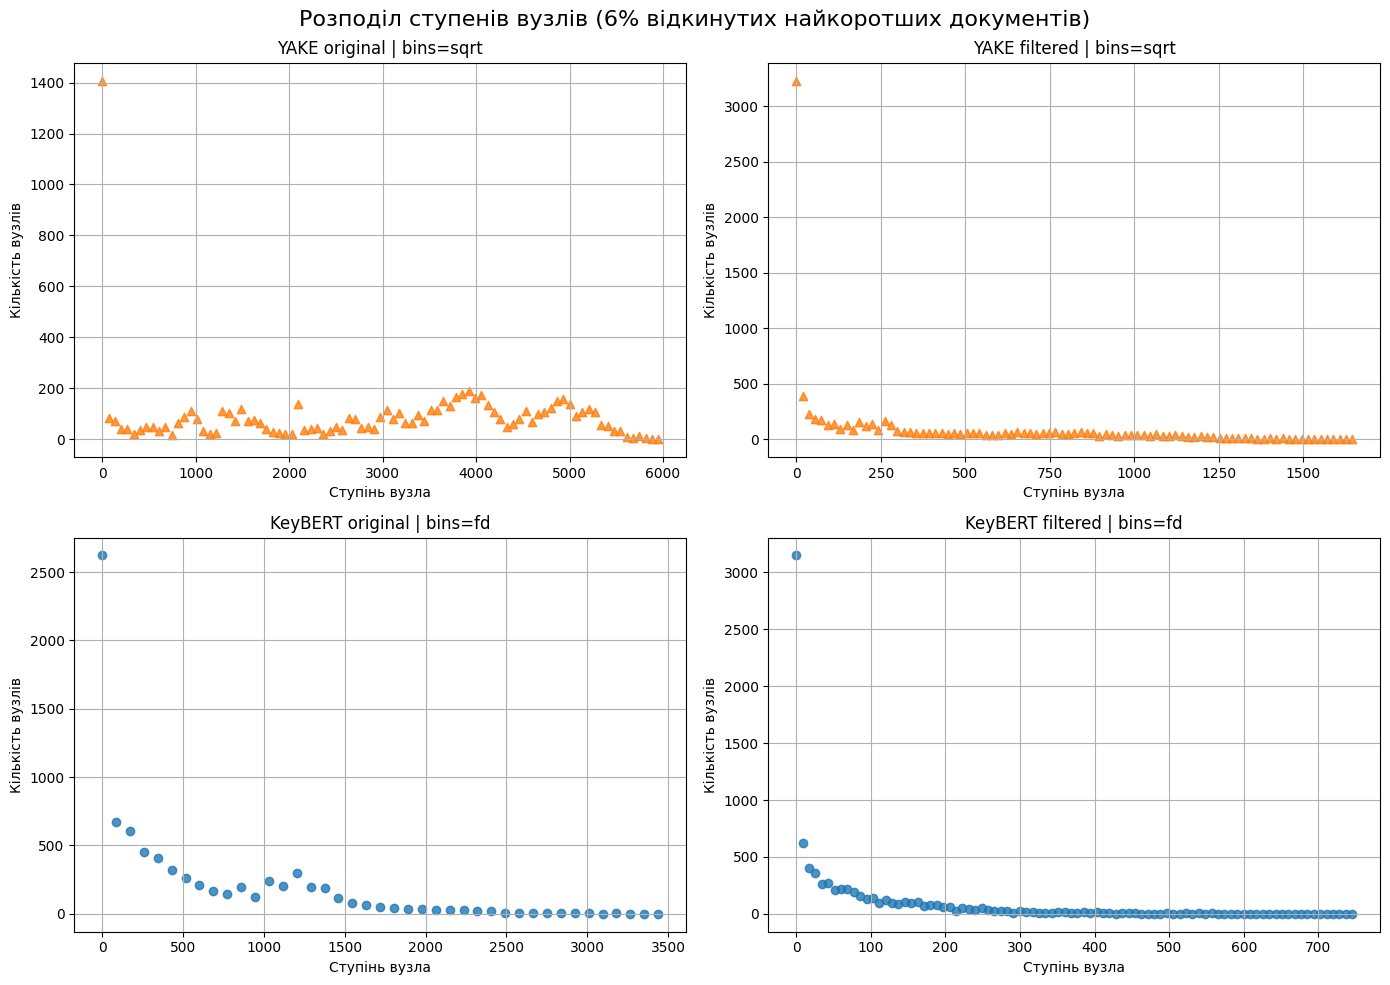

Saved: ..\dataset_comparative_2020_2026\comparative_files\network_figures\degree_distribution_4_variants_6pct.png


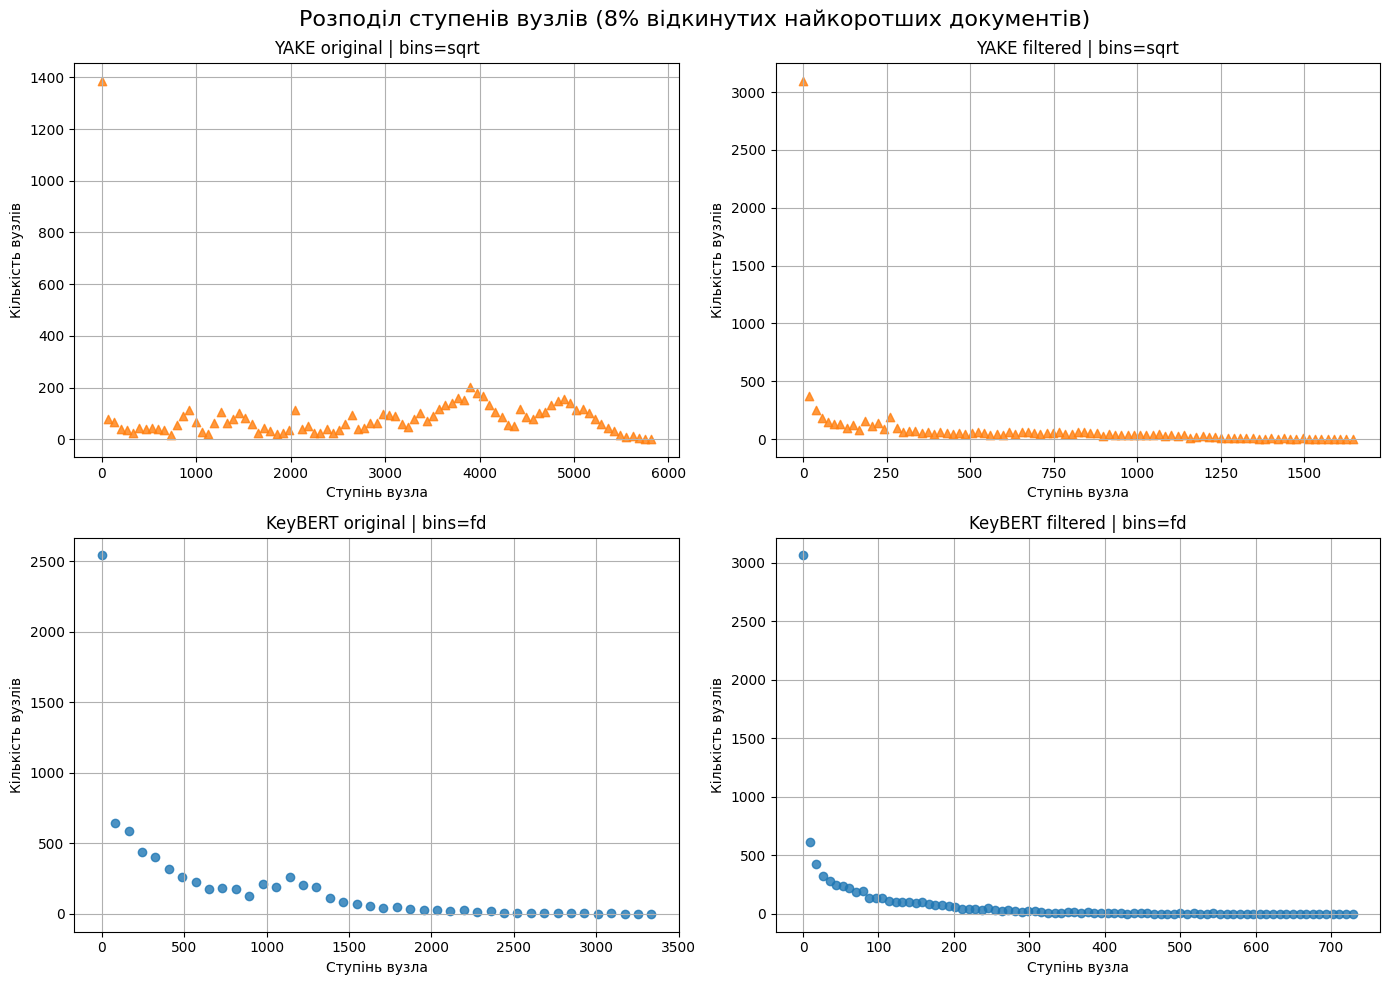

Saved: ..\dataset_comparative_2020_2026\comparative_files\network_figures\degree_distribution_4_variants_8pct.png


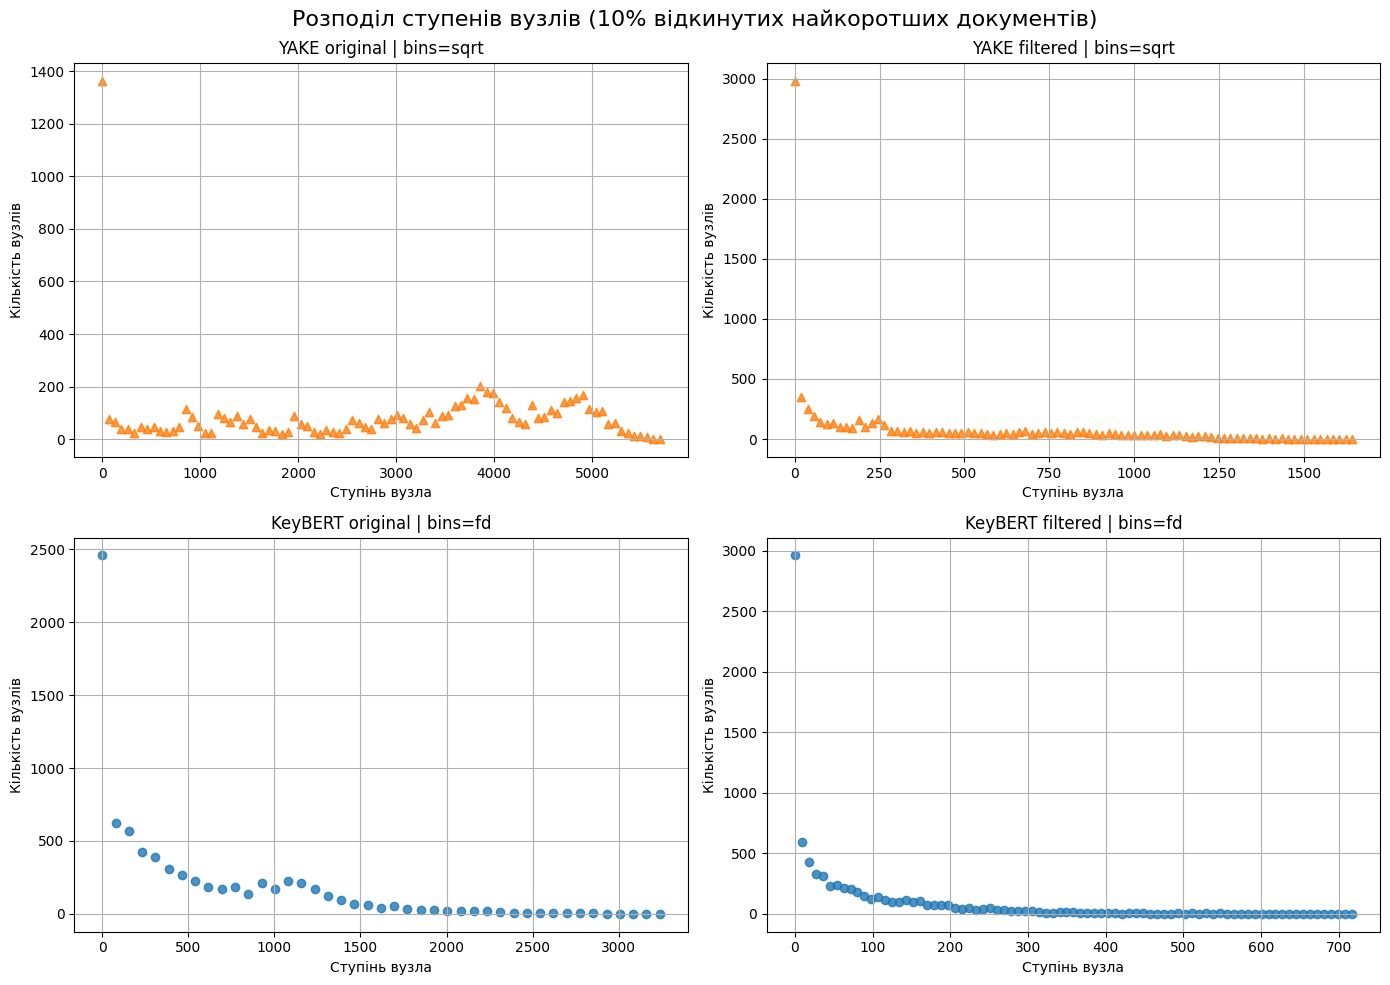

Saved: ..\dataset_comparative_2020_2026\comparative_files\network_figures\degree_distribution_4_variants_10pct.png


In [47]:
import numpy as np
import matplotlib.pyplot as plt
import json

FILTER_PERCENTS = [2, 4, 6, 8, 10]

variants = [
    ("YAKE", "original"),
    ("YAKE", "filtered"),
    ("KeyBERT", "original"),
    ("KeyBERT", "filtered"),
]

for filter_percent in FILTER_PERCENTS:

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (method, mode) in zip(axes, variants):
        degree_file = find_degree_file(method, mode, filter_percent)

        with open(degree_file, "r", encoding="utf-8") as f:
            degree_dist = json.load(f)

        data = []

        for degree, count in degree_dist.items():
            data.extend([int(degree)] * int(count))

        data = np.array(data)

        if method == "YAKE":
            bins_value = "sqrt"
        else:
            bins_value = "fd"

        hist, bin_edges = np.histogram(data, bins=bins_value)

        ax.scatter(
            bin_edges[:-1],
            hist,
            color=METHOD_COLORS.get(method),
            marker=METHOD_MARKERS.get(method, "o"),
            alpha=0.8
        )

        ax.set_title(f"{method} {mode} | bins={bins_value}")
        ax.set_xlabel("Ступінь вузла")
        ax.set_ylabel("Кількість вузлів")
        ax.grid(True)

    plt.suptitle(
        f"Розподіл ступенів вузлів ({filter_percent}% відкинутих найкоротших документів)",
        fontsize=16
    )

    plt.tight_layout()

    output_path = FIGURES_DIR / f"degree_distribution_4_variants_{filter_percent}pct.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

    print("Saved:", output_path)

In [38]:
clustering_path_df = summary_df[
    [
        "method",
        "mode",
        "filter_percent",
        "clustering_coefficient",
        "avg_shortest_path_length"
    ]
].sort_values(["method", "mode", "filter_percent"])

display(clustering_path_df)

output_path = COMPARATIVE_DIR / "clustering_and_avg_path_summary.csv"

clustering_path_df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", output_path)

,method,mode,filter_percent,clustering_coefficient,avg_shortest_path_length
0,KeyBERT,filtered,2,0.438143,2.8616
1,KeyBERT,filtered,4,0.432142,2.8624
2,KeyBERT,filtered,6,0.428593,2.8444
3,KeyBERT,filtered,8,0.422959,2.8081
4,KeyBERT,filtered,10,0.419197,2.7964
5,KeyBERT,original,2,0.593491,2.0588
6,KeyBERT,original,4,0.588746,2.0702
7,KeyBERT,original,6,0.585692,2.0785
8,KeyBERT,original,8,0.580442,2.0851
9,KeyBERT,original,10,0.575664,2.0612


Saved: ..\dataset_comparative_2020_2026\comparative_files\clustering_and_avg_path_summary.csv


In [39]:
metric_changes = []

for (method, mode), part in summary_df.groupby(["method", "mode"]):
    part = part.sort_values("filter_percent")

    row_2 = part[part["filter_percent"] == 2].iloc[0]
    row_10 = part[part["filter_percent"] == 10].iloc[0]

    clustering_change = row_10["clustering_coefficient"] - row_2["clustering_coefficient"]
    avg_path_change = row_10["avg_shortest_path_length"] - row_2["avg_shortest_path_length"]

    metric_changes.append({
        "method": method,
        "mode": mode,
        "clustering_2pct": row_2["clustering_coefficient"],
        "clustering_10pct": row_10["clustering_coefficient"],
        "clustering_change": round(clustering_change, 6),
        "clustering_change_percent": round(clustering_change / row_2["clustering_coefficient"] * 100, 2),

        "avg_path_2pct": row_2["avg_shortest_path_length"],
        "avg_path_10pct": row_10["avg_shortest_path_length"],
        "avg_path_change": round(avg_path_change, 6),
        "avg_path_change_percent": round(avg_path_change / row_2["avg_shortest_path_length"] * 100, 2),
    })

metric_changes_df = pd.DataFrame(metric_changes)

display(metric_changes_df)

output_path = COMPARATIVE_DIR / "clustering_avg_path_changes_2pct_10pct.csv"
metric_changes_df.to_csv(output_path, index=False, encoding="utf-8-sig")

print("Saved:", output_path)

,method,mode,clustering_2pct,clustering_10pct,clustering_change,clustering_change_percent,avg_path_2pct,avg_path_10pct,avg_path_change,avg_path_change_percent
0,KeyBERT,filtered,0.438143,0.419197,-0.018946,-4.32,2.8616,2.7964,-0.0652,-2.28
1,KeyBERT,original,0.593491,0.575664,-0.017827,-3.00,2.0588,2.0612,0.0024,0.12
2,YAKE,filtered,0.659367,0.651838,-0.007529,-1.14,2.4241,2.3416,-0.0825,-3.40
3,YAKE,original,0.816154,0.830108,0.013954,1.71,1.5699,1.4858,-0.0841,-5.36


Saved: ..\dataset_comparative_2020_2026\comparative_files\clustering_avg_path_changes_2pct_10pct.csv


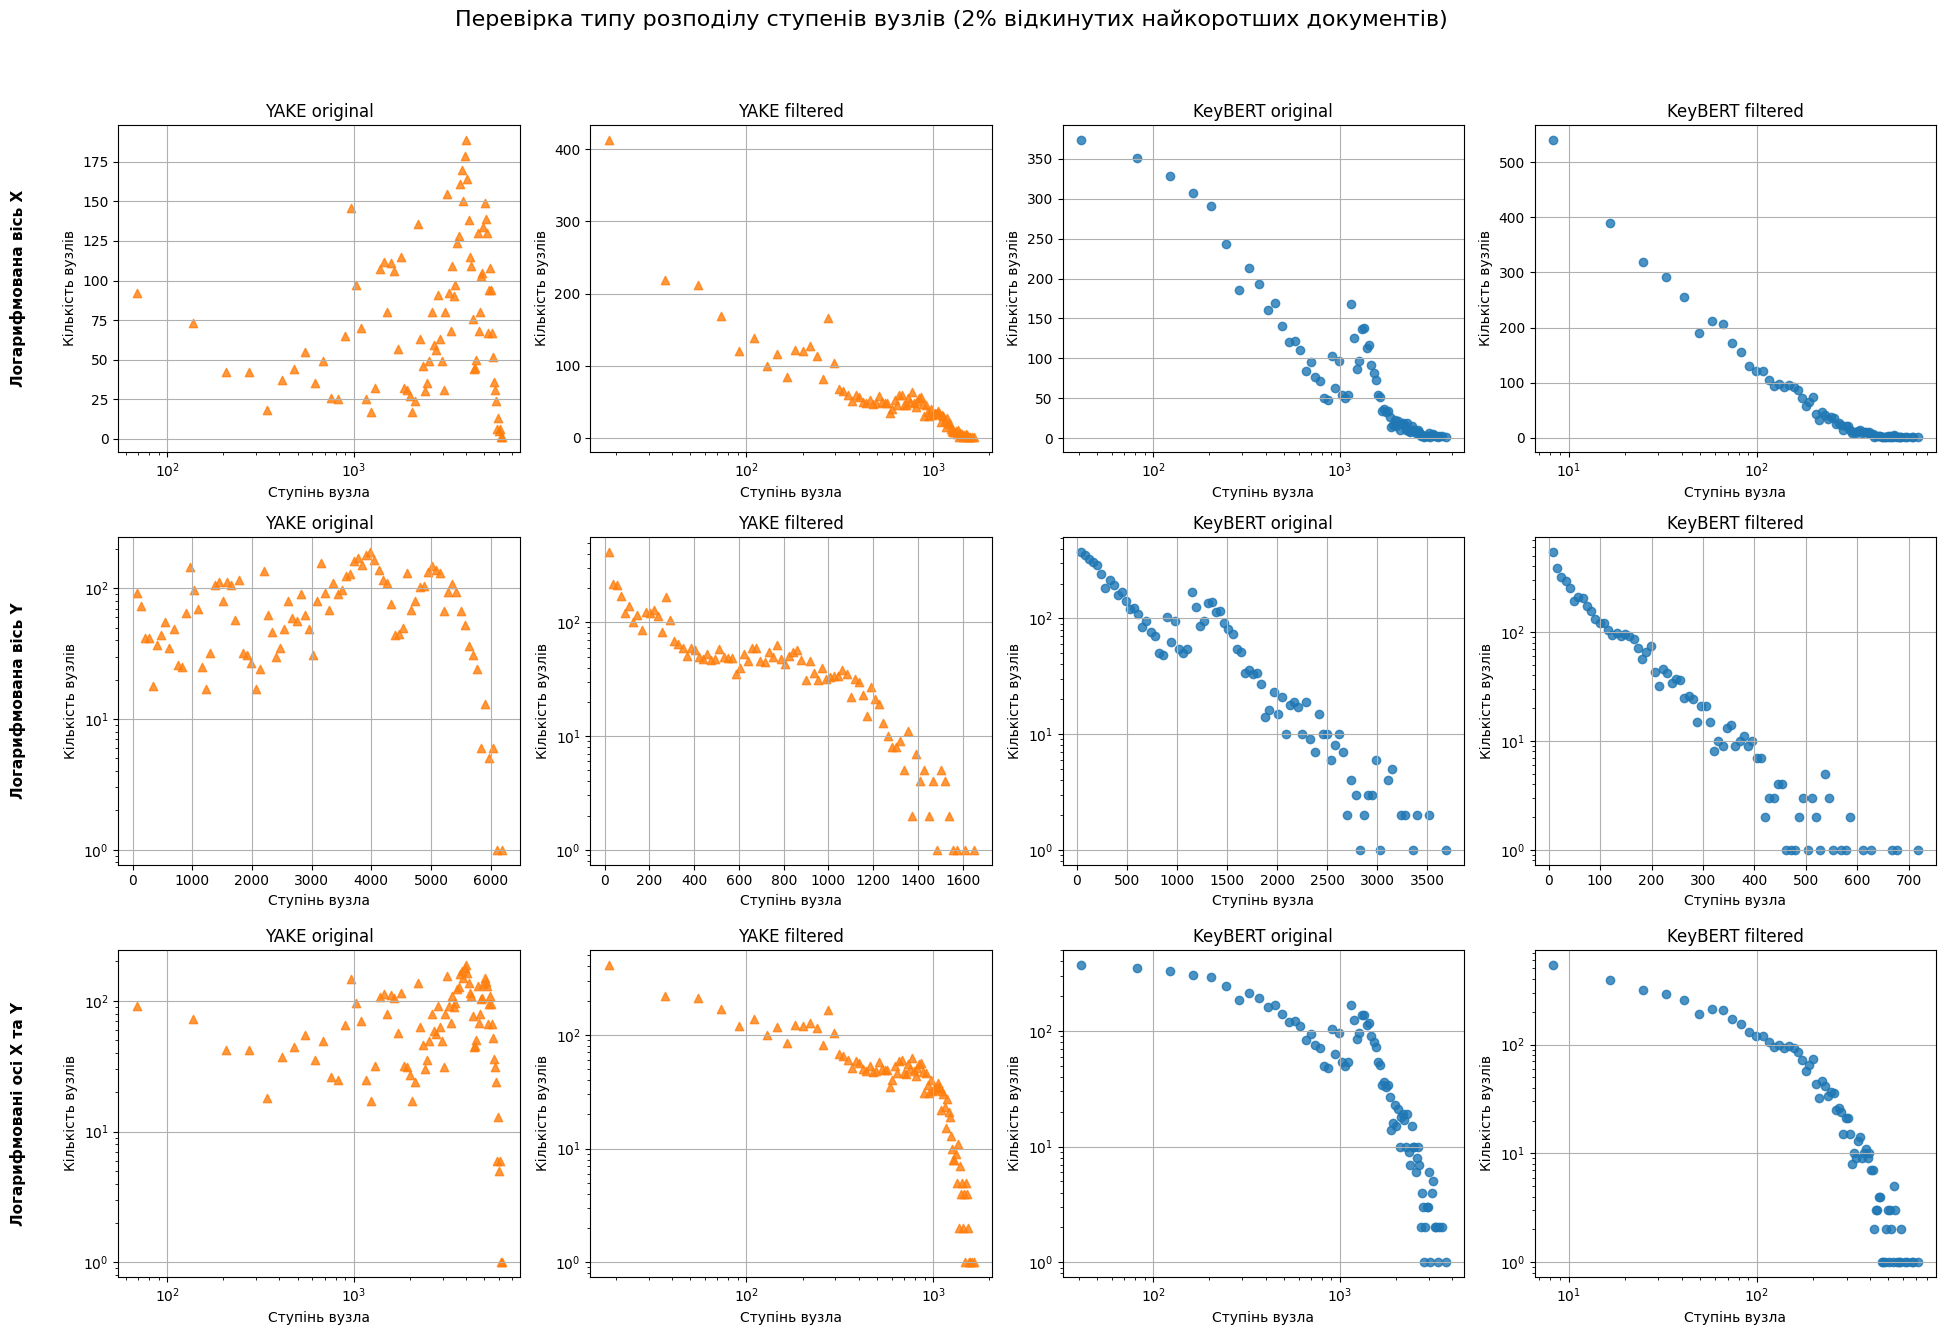

Saved: ..\dataset_comparative_2020_2026\comparative_files\network_figures\degree_distribution_scale_check_2pct.png


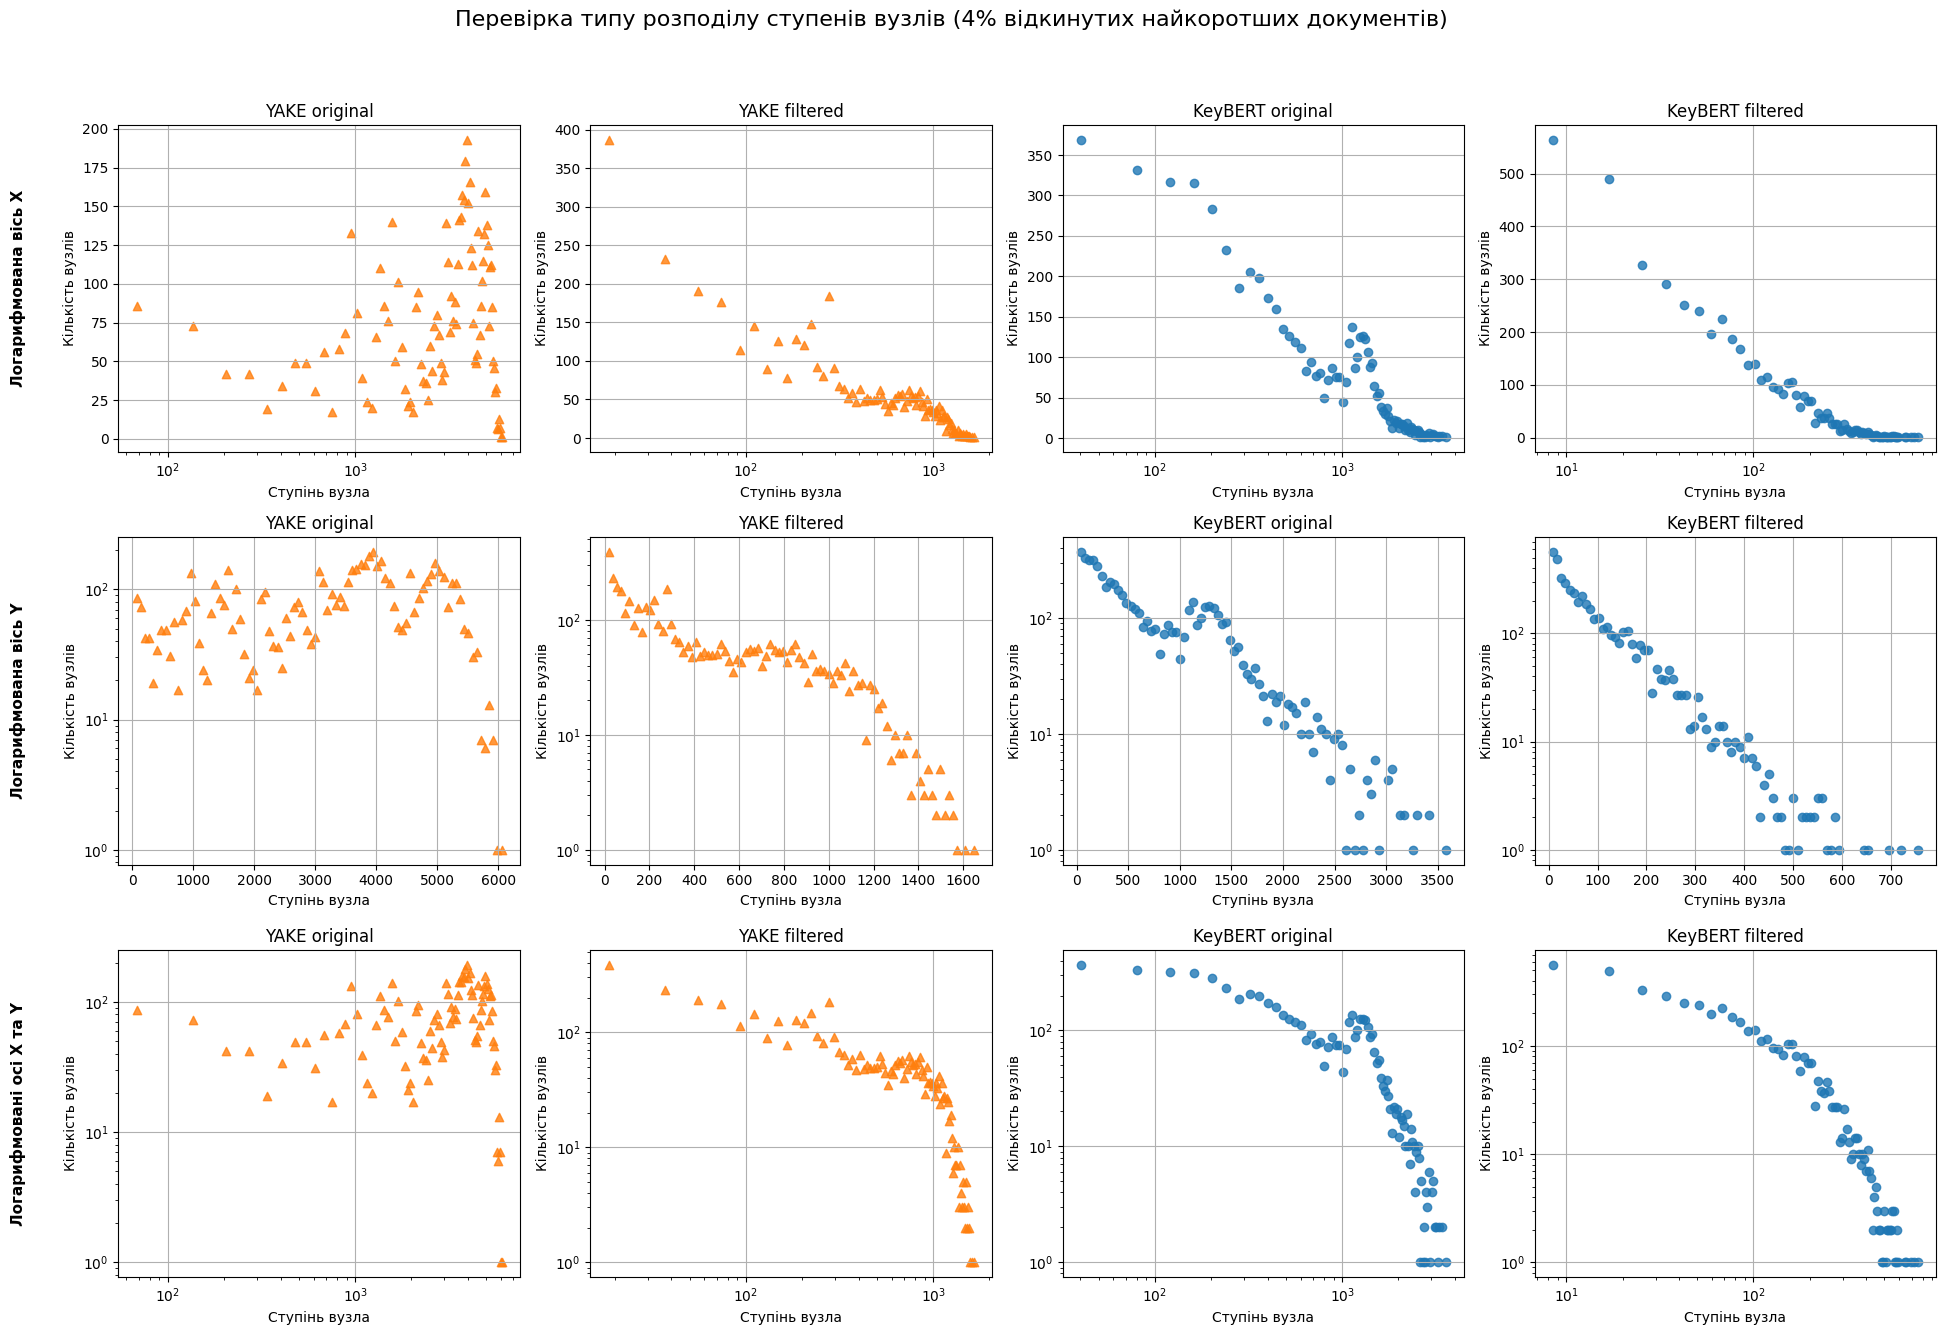

Saved: ..\dataset_comparative_2020_2026\comparative_files\network_figures\degree_distribution_scale_check_4pct.png


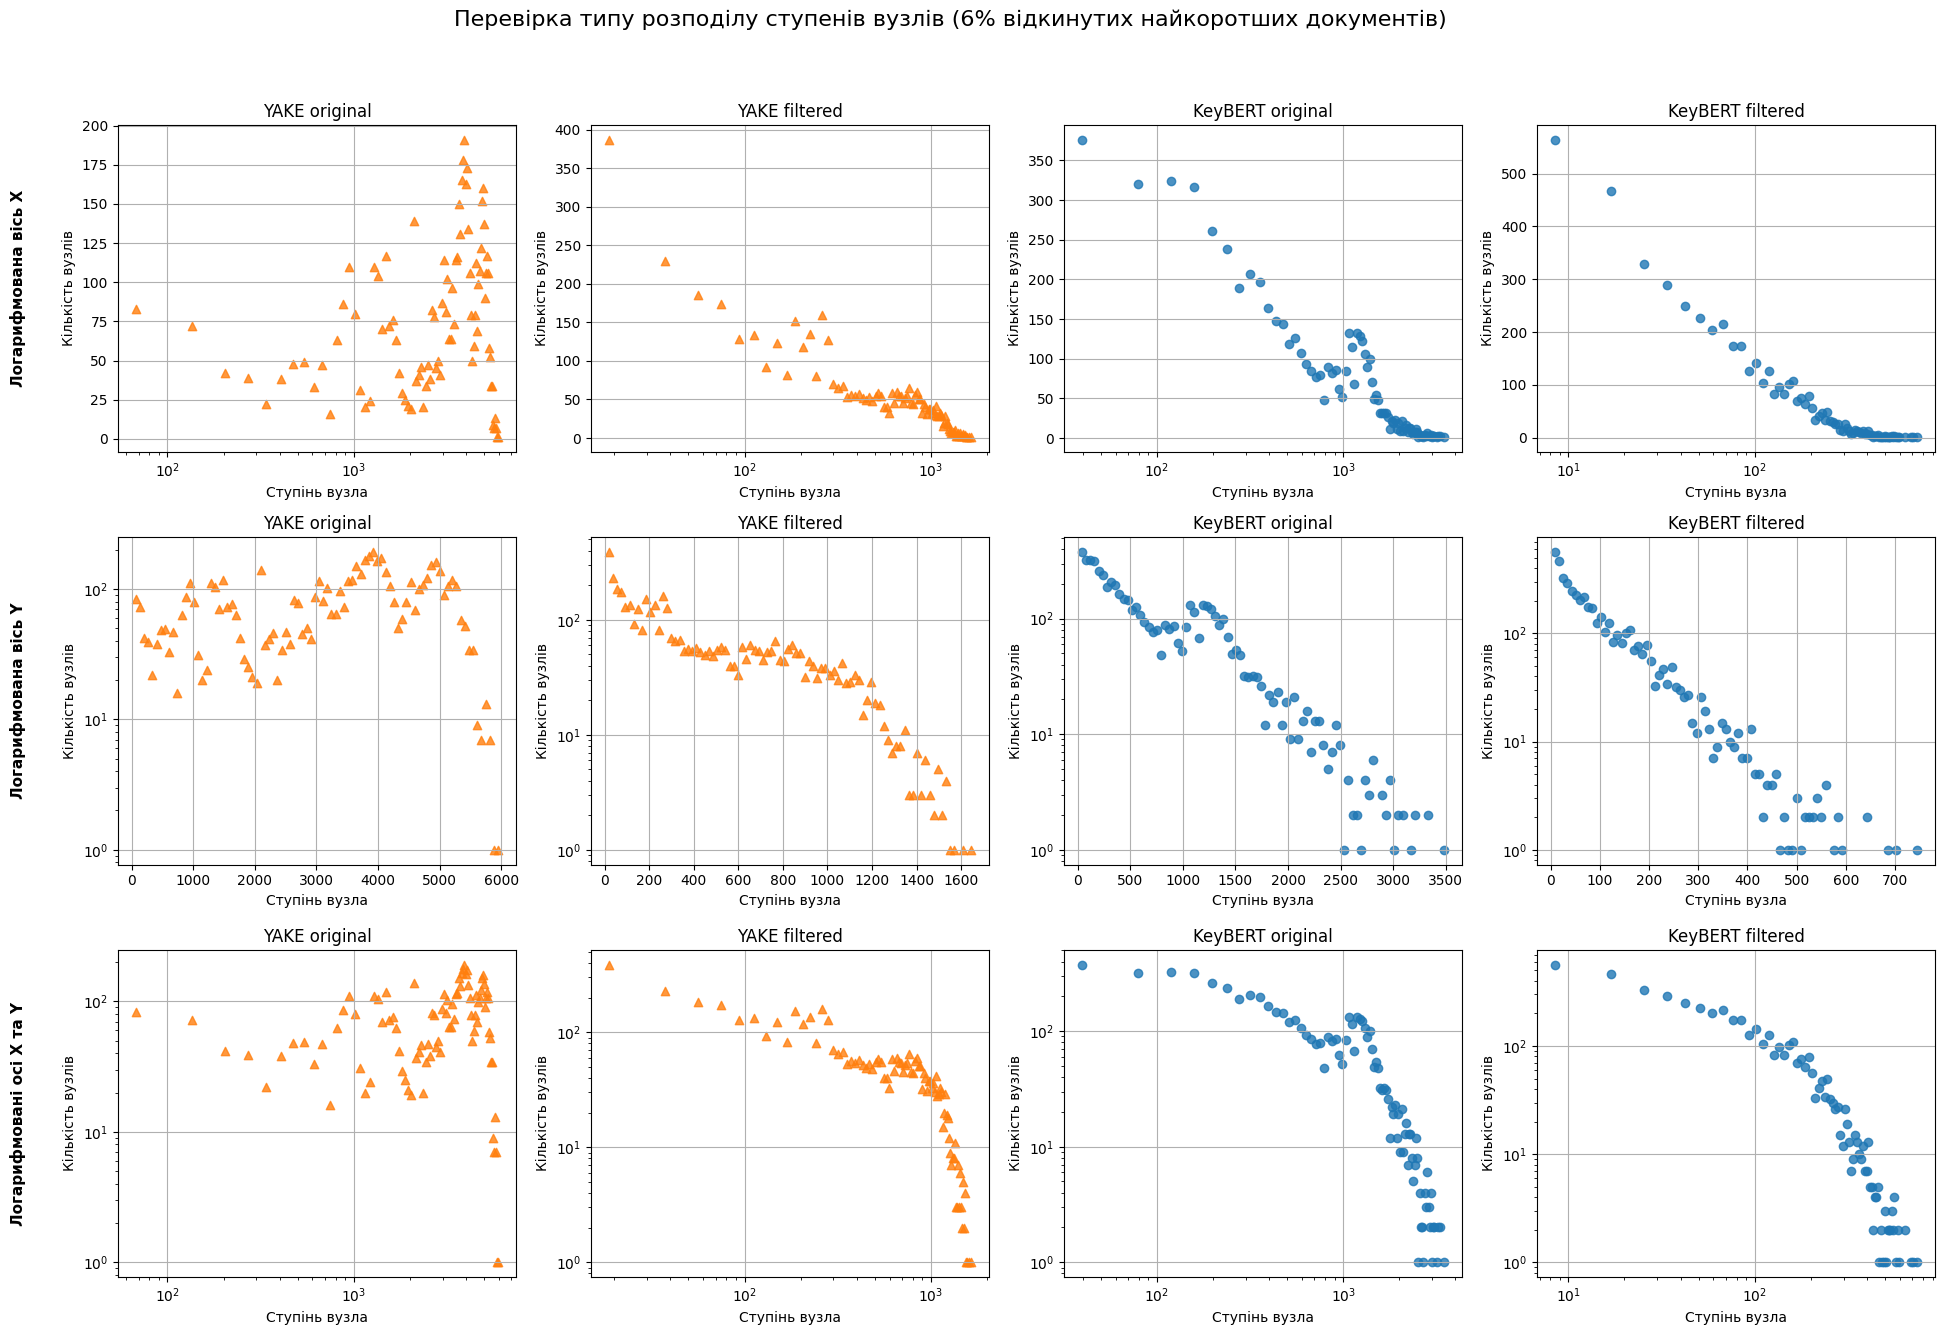

Saved: ..\dataset_comparative_2020_2026\comparative_files\network_figures\degree_distribution_scale_check_6pct.png


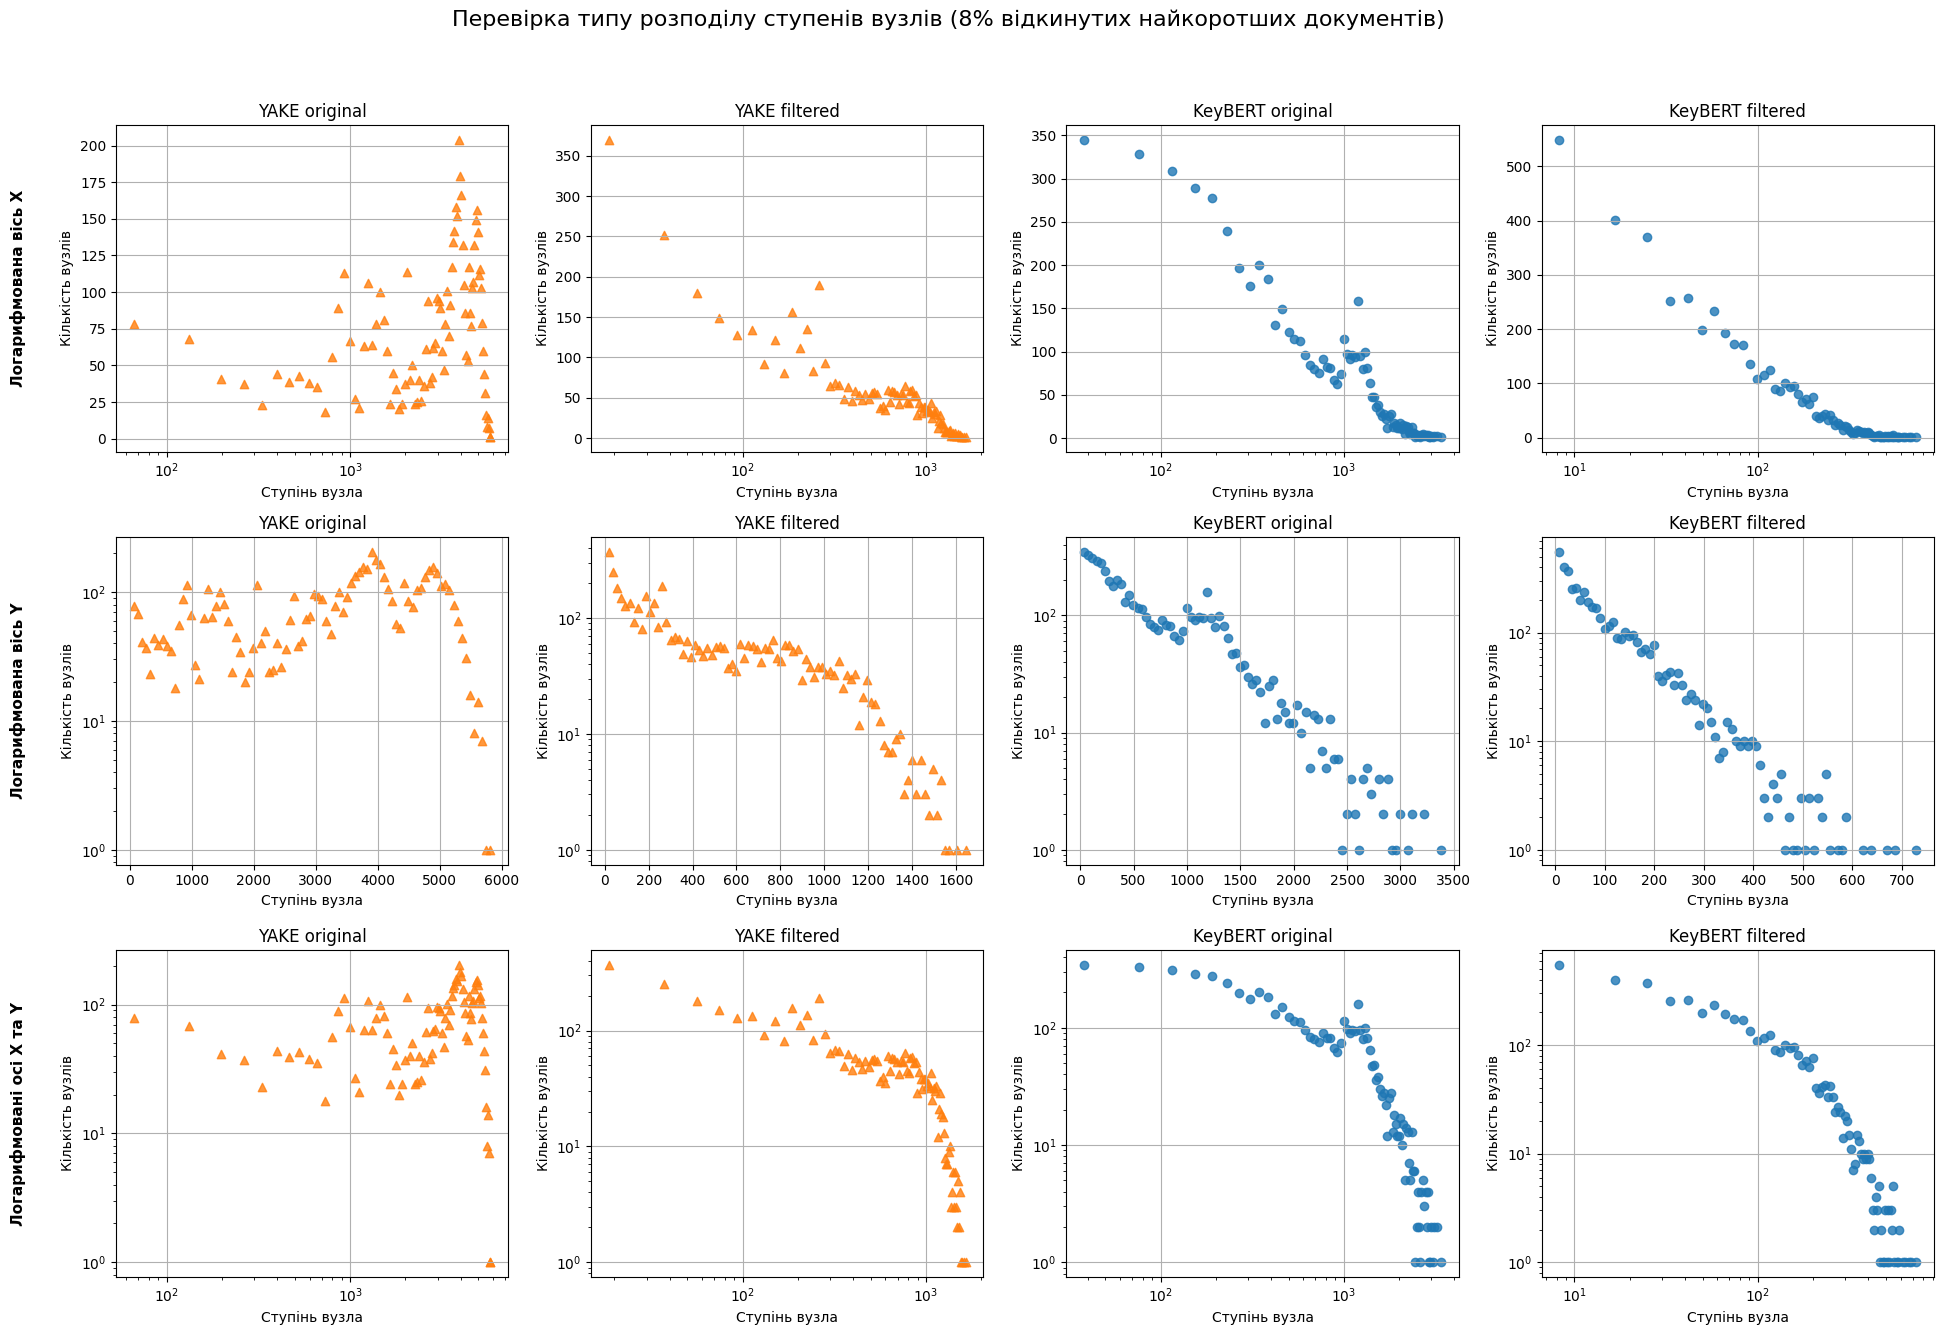

Saved: ..\dataset_comparative_2020_2026\comparative_files\network_figures\degree_distribution_scale_check_8pct.png


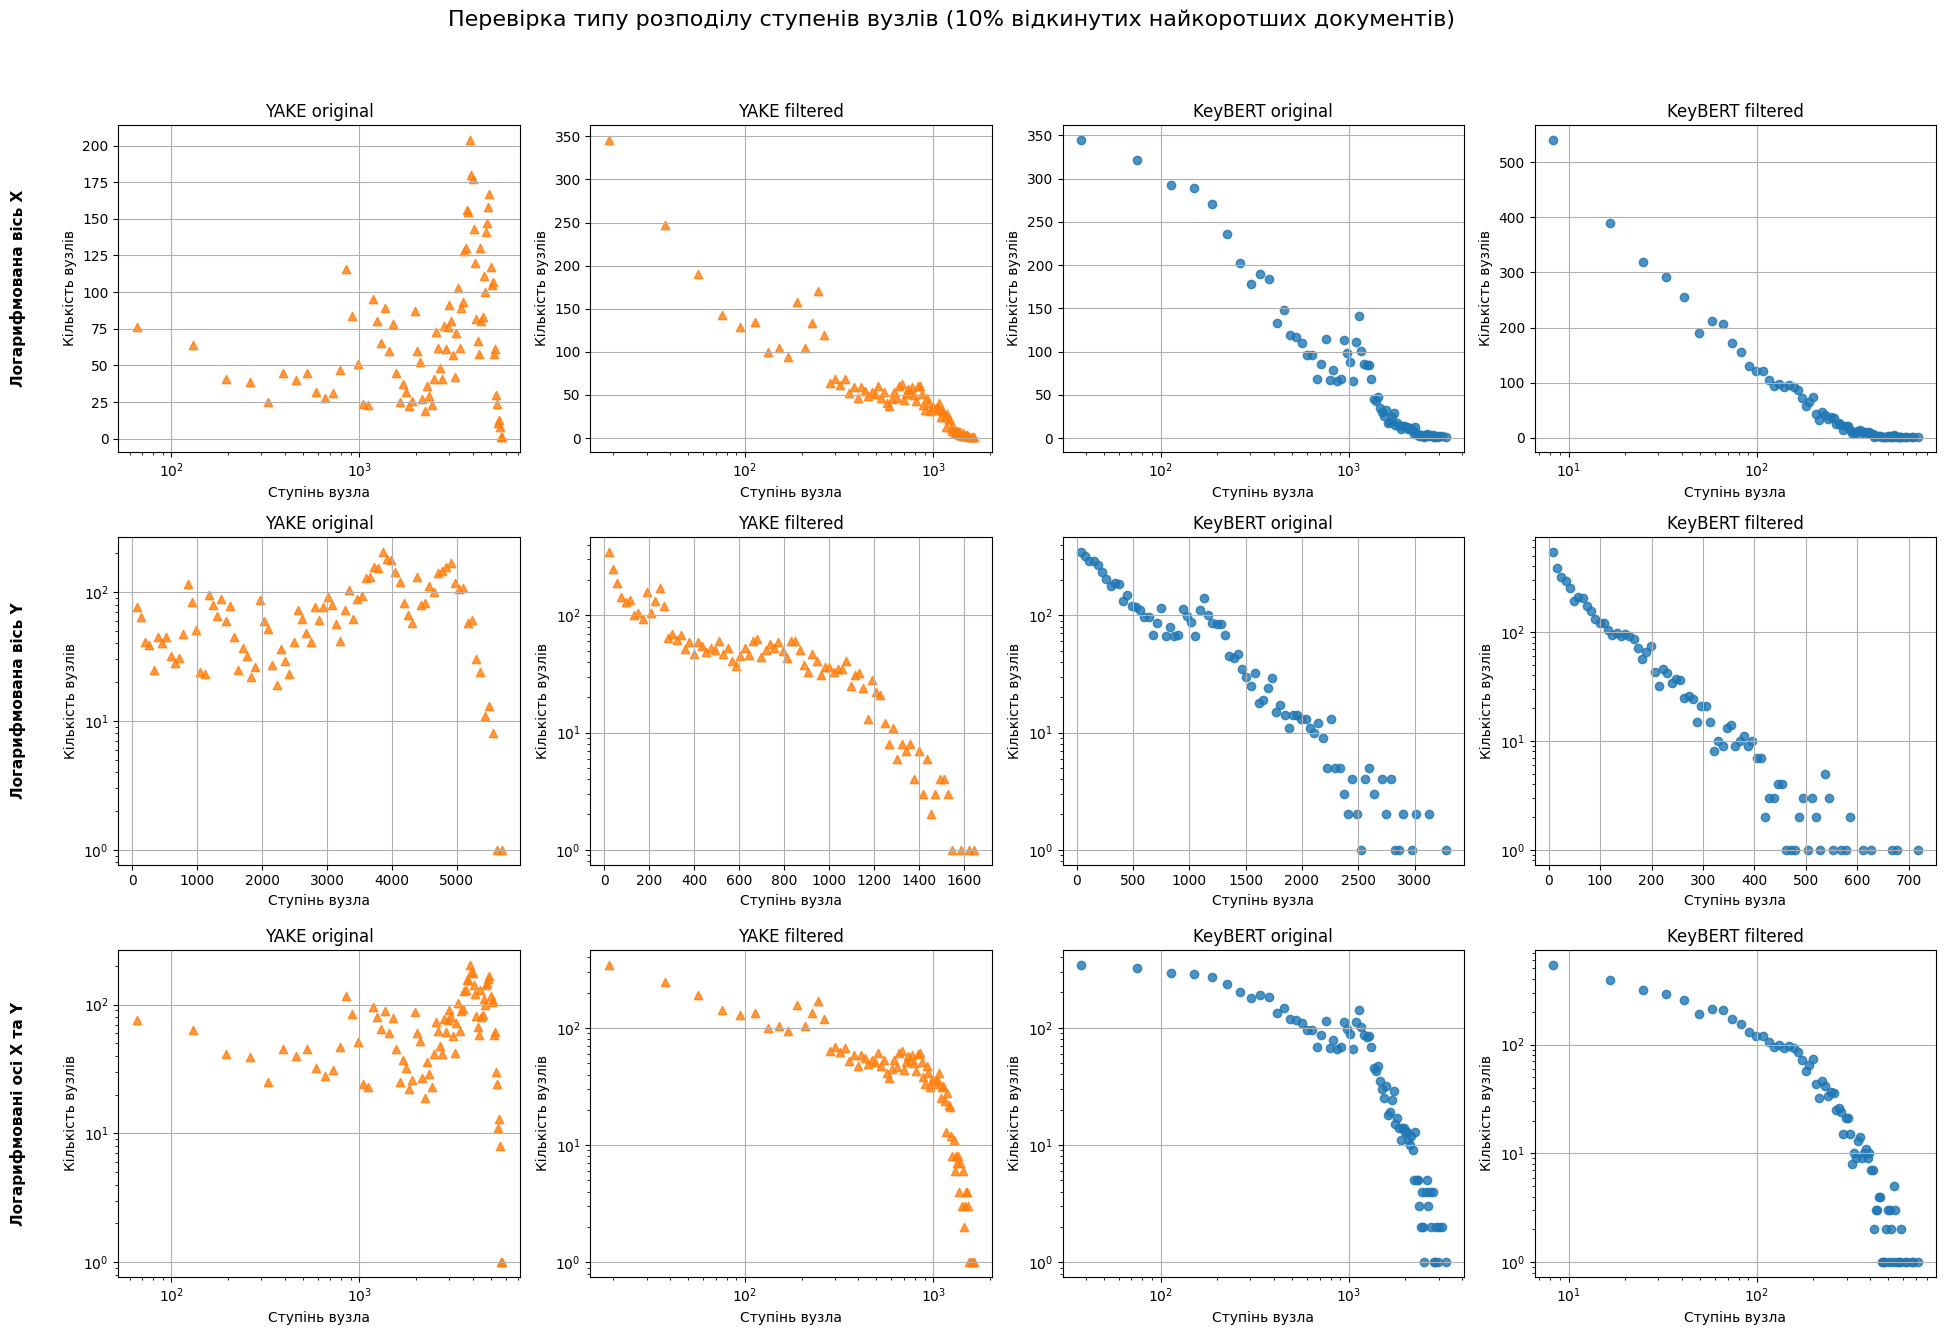

Saved: ..\dataset_comparative_2020_2026\comparative_files\network_figures\degree_distribution_scale_check_10pct.png


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import json

FILTER_PERCENTS = [2, 4, 6, 8, 10]

variants = [
    ("YAKE", "original"),
    ("YAKE", "filtered"),
    ("KeyBERT", "original"),
    ("KeyBERT", "filtered"),
]

scale_variants = [
    ("log_x", "Логарифмована вісь X"),
    ("log_y", "Логарифмована вісь Y"),
    ("log_xy", "Логарифмовані осі X та Y"),
]

for filter_percent in FILTER_PERCENTS:

    fig, axes = plt.subplots(3, 4, figsize=(20, 14))

    for col_idx, (method, mode) in enumerate(variants):
        degree_file = find_degree_file(method, mode, filter_percent)

        with open(degree_file, "r", encoding="utf-8") as f:
            degree_dist = json.load(f)

        data = []

        for degree, count in degree_dist.items():
            data.extend([int(degree)] * int(count))

        data = np.array(data)

        if method == "YAKE":
            bins_value = "sqrt"
        else:
            bins_value = "sqrt"

        hist, bin_edges = np.histogram(data, bins=bins_value)

        x = bin_edges[:-1]
        y = hist

        # Для log-масштабу треба прибрати нулі, бо log(0) неможливий.
        mask = (x > 0) & (y > 0)
        x = x[mask]
        y = y[mask]

        for row_idx, (scale_type, row_title) in enumerate(scale_variants):
            ax = axes[row_idx, col_idx]

            ax.scatter(
                x,
                y,
                color=METHOD_COLORS.get(method),
                marker=METHOD_MARKERS.get(method, "o"),
                alpha=0.8
            )

            if scale_type == "log_x":
                ax.set_xscale("log")
            elif scale_type == "log_y":
                ax.set_yscale("log")
            elif scale_type == "log_xy":
                ax.set_xscale("log")
                ax.set_yscale("log")

            ax.set_title(f"{method} {mode}")
            ax.set_xlabel("Ступінь вузла")
            ax.set_ylabel("Кількість вузлів")
            ax.grid(True)

            if col_idx == 0:
                ax.text(
                    -0.25,
                    0.5,
                    row_title,
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=11,
                    fontweight="bold"
                )

    plt.suptitle(
        f"Перевірка типу розподілу ступенів вузлів ({filter_percent}% відкинутих найкоротших документів)",
        fontsize=16
    )

    plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])

    output_path = FIGURES_DIR / f"degree_distribution_scale_check_{filter_percent}pct.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

    print("Saved:", output_path)